<a href="https://colab.research.google.com/github/adwait-ops/GW-ODW-2025/blob/main/Challenge_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q lalsuite gwpy pycbc

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 MB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 74.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 81.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.2/45.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.0/115.0 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.7/168.7 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.1/48.1 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 118.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

In [2]:
from google.colab import files

uploaded = files.upload()

Saving challenge3.gwf to challenge3.gwf


Challenge 3 Results:
Merger Time: 4090.0579 seconds
Matched Filter SNR: 786.28


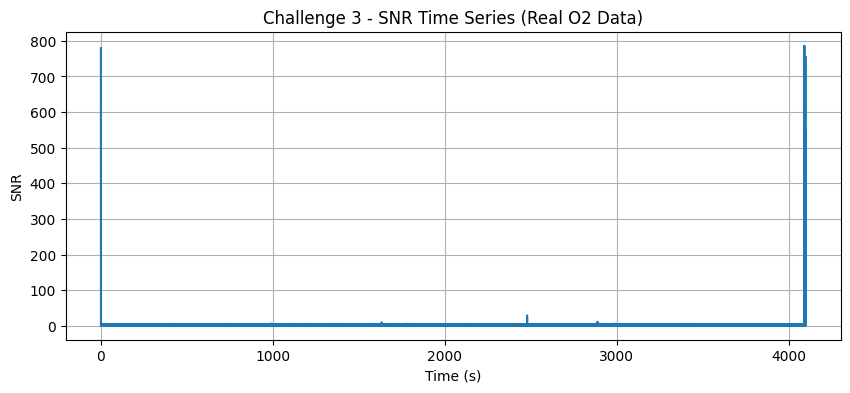

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from pycbc import frame
from pycbc.waveform import get_td_waveform
from pycbc.filter import matched_filter
from pycbc.psd import interpolate, inverse_spectrum_truncation

#load data
file_path = 'challenge3.gwf'
channel_name = "H1:CHALLENGE3"
strain = frame.read_frame(file_path, channel_name)

#generate tempelate waveform
hp, hc = get_td_waveform(approximant="SEOBNRv4_opt",
                         mass1=10, mass2=10,
                         delta_t=strain.delta_t, f_lower=20)
hp.resize(len(strain))

#calculate psd
psd = strain.psd(8)
psd = interpolate(psd, strain.delta_f)
psd = inverse_spectrum_truncation(psd, int(8 * strain.sample_rate), low_frequency_cutoff=20)

#matched filter
snr = matched_filter(hp, strain, psd=psd, low_frequency_cutoff=20)
snr_segment = snr.crop(4, 4) # Crop to avoid edge effects

#extract the peak
snr_array = np.absolute(snr_segment.numpy())
peak_idx = snr_array.argmax()
peak_time = snr_segment.sample_times[peak_idx]
peak_snr = snr_array[peak_idx]

print(f"Challenge 3 Results:")
print(f"Merger Time: {peak_time:.4f} seconds")
print(f"Matched Filter SNR: {peak_snr:.2f}")

#plot
plt.figure(figsize=(10, 4))
plt.plot(snr.sample_times, np.absolute(snr))
plt.title("Challenge 3 - SNR Time Series (Real O2 Data)")
plt.ylabel("SNR")
plt.xlabel("Time (s)")
plt.grid()
plt.show()